In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
folder = "/content/drive/MyDrive/Project2_SolarPV"
print(os.listdir(folder))

['Plant_1_Generation_Data.csv', 'Plant_2_Generation_Data.csv', 'Plant_1_Weather_Sensor_Data.csv', 'Plant_2_Weather_Sensor_Data.csv', 'eda_initial.png']


MERGED DATASET — FINAL
Shape: (3157, 6)
Columns: ['DATE_TIME', 'DC_POWER', 'AC_POWER', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']

DESCRIPTIVE STATISTICS
                           DATE_TIME    DC_POWER   AC_POWER  \
count                           3157    3157.000   3157.000   
mean   2020-06-01 06:41:41.298701568   68560.020   6704.831   
min              2020-05-15 00:00:00       0.000      0.000   
25%              2020-05-23 23:15:00       0.000      0.000   
50%              2020-06-01 12:30:00    8430.196    814.880   
75%              2020-06-09 18:00:00  140409.893  13752.112   
max              2020-06-17 23:45:00  298937.786  29150.212   
std                              NaN   88055.844   8604.218   

       AMBIENT_TEMPERATURE  MODULE_TEMPERATURE  IRRADIATION  
count             3157.000            3157.000     3157.000  
mean                25.560              31.175        0.230  
min                 20.399              18.140        0.000  
25%          

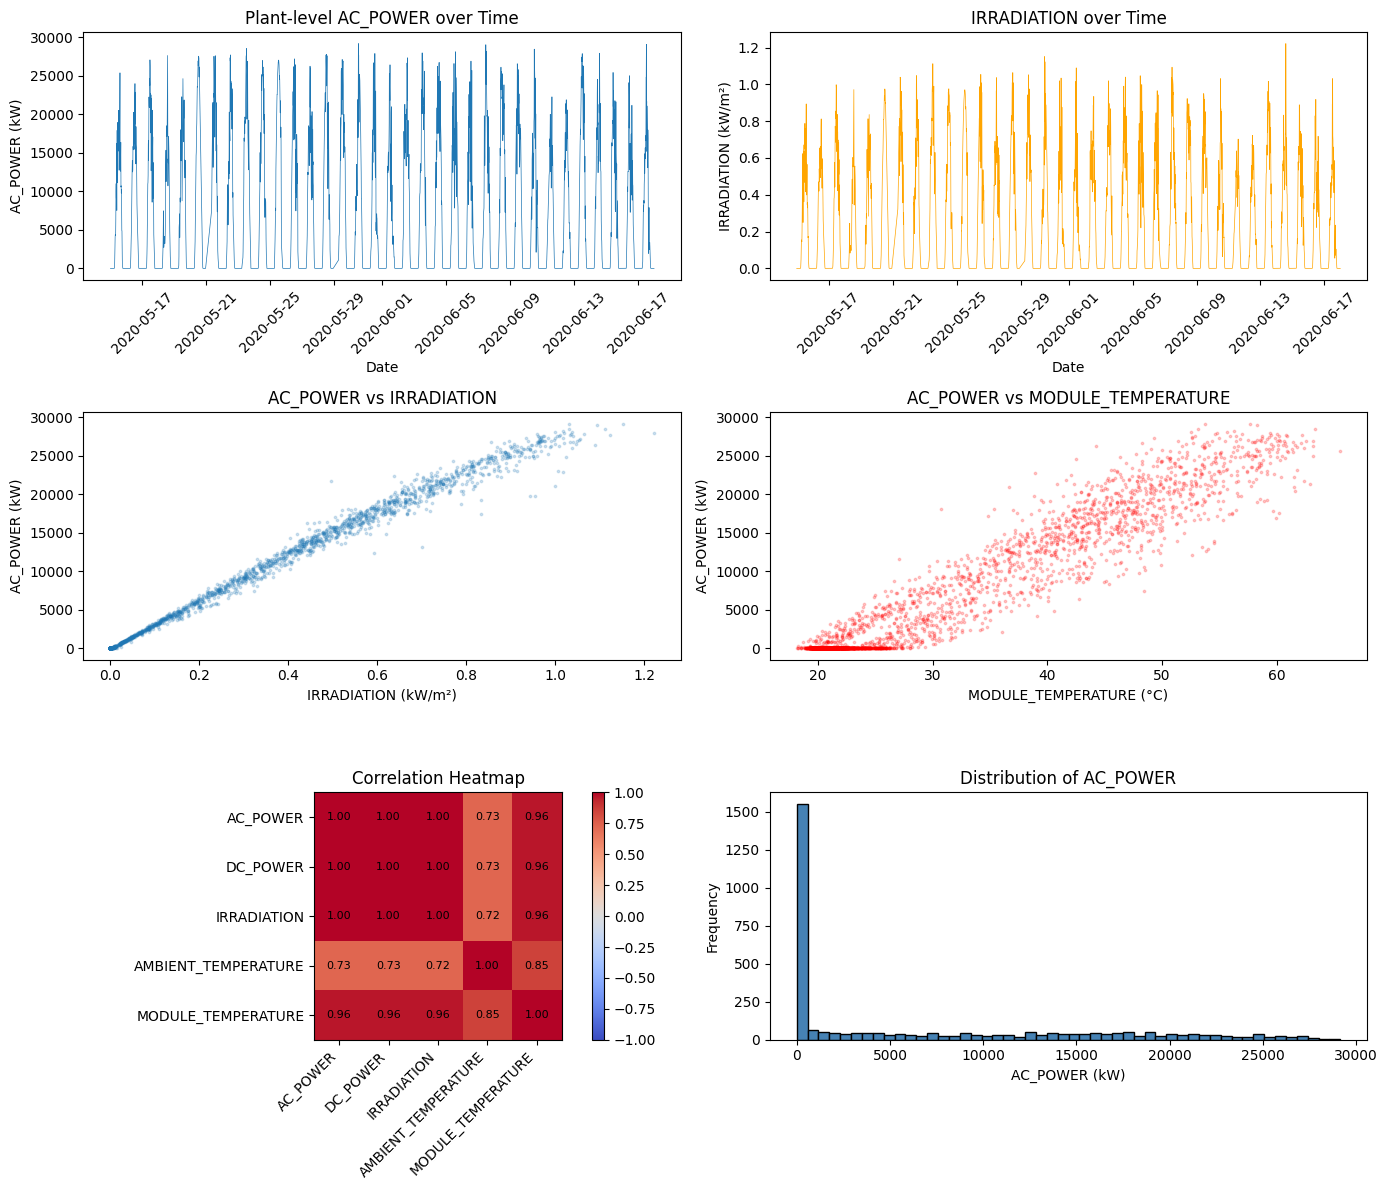


EDA plot saved to: Project2_SolarPV/eda_initial.png


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

folder = "/content/drive/MyDrive/Project2_SolarPV/"

# Load Plant 1 only
gen = pd.read_csv(folder + "Plant_1_Generation_Data.csv")
wth = pd.read_csv(folder + "Plant_1_Weather_Sensor_Data.csv")

# Correct date parsing
gen["DATE_TIME"] = pd.to_datetime(gen["DATE_TIME"], format="%d-%m-%Y %H:%M")
wth["DATE_TIME"] = pd.to_datetime(wth["DATE_TIME"], format="%Y-%m-%d %H:%M:%S")

# Aggregate to plant level
gen_plant = gen.groupby("DATE_TIME").agg({
    "DC_POWER": "sum",
    "AC_POWER": "sum",
}).reset_index()

# Merge with weather
wth_clean = wth[["DATE_TIME", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE", "IRRADIATION"]].copy()
df = pd.merge(gen_plant, wth_clean, on="DATE_TIME", how="inner")

print("=" * 70)
print("MERGED DATASET — FINAL")
print("=" * 70)
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
print()

# Descriptive statistics
print("=" * 70)
print("DESCRIPTIVE STATISTICS")
print("=" * 70)
print(df.describe().round(3))

# Timestamp continuity check
print("\n" + "=" * 70)
print("TIMESTAMP CONTINUITY CHECK")
print("=" * 70)
time_diffs = df["DATE_TIME"].diff().dropna()
print("Most common time differences:")
print(time_diffs.value_counts().head(10))

# Hourly pattern
print("\n" + "=" * 70)
print("HOURLY AVERAGES (mean across all days)")
print("=" * 70)
df["HOUR"] = df["DATE_TIME"].dt.hour
hourly = df.groupby("HOUR")[["AC_POWER", "IRRADIATION", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE"]].mean().round(3)
print(hourly)

# EDA plots
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

axes[0, 0].plot(df["DATE_TIME"], df["AC_POWER"], linewidth=0.5)
axes[0, 0].set_title("Plant-level AC_POWER over Time")
axes[0, 0].set_xlabel("Date")
axes[0, 0].set_ylabel("AC_POWER (kW)")
axes[0, 0].tick_params(axis="x", rotation=45)

axes[0, 1].plot(df["DATE_TIME"], df["IRRADIATION"], linewidth=0.5, color="orange")
axes[0, 1].set_title("IRRADIATION over Time")
axes[0, 1].set_xlabel("Date")
axes[0, 1].set_ylabel("IRRADIATION (kW/m²)")
axes[0, 1].tick_params(axis="x", rotation=45)

axes[1, 0].scatter(df["IRRADIATION"], df["AC_POWER"], alpha=0.2, s=3)
axes[1, 0].set_title("AC_POWER vs IRRADIATION")
axes[1, 0].set_xlabel("IRRADIATION (kW/m²)")
axes[1, 0].set_ylabel("AC_POWER (kW)")

axes[1, 1].scatter(df["MODULE_TEMPERATURE"], df["AC_POWER"], alpha=0.2, s=3, color="red")
axes[1, 1].set_title("AC_POWER vs MODULE_TEMPERATURE")
axes[1, 1].set_xlabel("MODULE_TEMPERATURE (°C)")
axes[1, 1].set_ylabel("AC_POWER (kW)")

corr = df[["AC_POWER", "DC_POWER", "IRRADIATION", "AMBIENT_TEMPERATURE", "MODULE_TEMPERATURE"]].corr()
im = axes[2, 0].imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
axes[2, 0].set_xticks(range(len(corr.columns)))
axes[2, 0].set_yticks(range(len(corr.columns)))
axes[2, 0].set_xticklabels(corr.columns, rotation=45, ha="right")
axes[2, 0].set_yticklabels(corr.columns)
axes[2, 0].set_title("Correlation Heatmap")
plt.colorbar(im, ax=axes[2, 0])
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        axes[2, 0].text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

axes[2, 1].hist(df["AC_POWER"], bins=50, color="steelblue", edgecolor="black")
axes[2, 1].set_title("Distribution of AC_POWER")
axes[2, 1].set_xlabel("AC_POWER (kW)")
axes[2, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Project2_SolarPV/eda_initial.png", dpi=100)
plt.show()

print("\n" + "=" * 70)
print("EDA plot saved to: Project2_SolarPV/eda_initial.png")
print("=" * 70)